In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import nltk

## Loading Data

In [3]:
nltk.download('treebank')

[nltk_data] Downloading package treebank to /usr/share/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [4]:
data = nltk.corpus.treebank.tagged_sents()
data

[[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')], [('Mr.', 'NNP'), ('Vinken', 'NNP'), ('is', 'VBZ'), ('chairman', 'NN'), ('of', 'IN'), ('Elsevier', 'NNP'), ('N.V.', 'NNP'), (',', ','), ('the', 'DT'), ('Dutch', 'NNP'), ('publishing', 'VBG'), ('group', 'NN'), ('.', '.')], ...]

In [5]:
len(data)

3914

In [6]:
data[0]

[('Pierre', 'NNP'),
 ('Vinken', 'NNP'),
 (',', ','),
 ('61', 'CD'),
 ('years', 'NNS'),
 ('old', 'JJ'),
 (',', ','),
 ('will', 'MD'),
 ('join', 'VB'),
 ('the', 'DT'),
 ('board', 'NN'),
 ('as', 'IN'),
 ('a', 'DT'),
 ('nonexecutive', 'JJ'),
 ('director', 'NN'),
 ('Nov.', 'NNP'),
 ('29', 'CD'),
 ('.', '.')]

In [7]:
texts, labels = [], []
for row in data:
    text, label = zip(*row)
    texts.append([word for word in text])
    labels.append([tag for tag in label])


In [8]:
texts[1]

['Mr.',
 'Vinken',
 'is',
 'chairman',
 'of',
 'Elsevier',
 'N.V.',
 ',',
 'the',
 'Dutch',
 'publishing',
 'group',
 '.']

In [9]:
labels[1]

['NNP',
 'NNP',
 'VBZ',
 'NN',
 'IN',
 'NNP',
 'NNP',
 ',',
 'DT',
 'NNP',
 'VBG',
 'NN',
 '.']

## Tokenizer

In [10]:
from transformers import AutoTokenizer
model_name = 'distilbert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
count = [len(tokenizer.encode(text, is_split_into_words=True)) for text in texts]

Text(0, 0.5, 'freq')

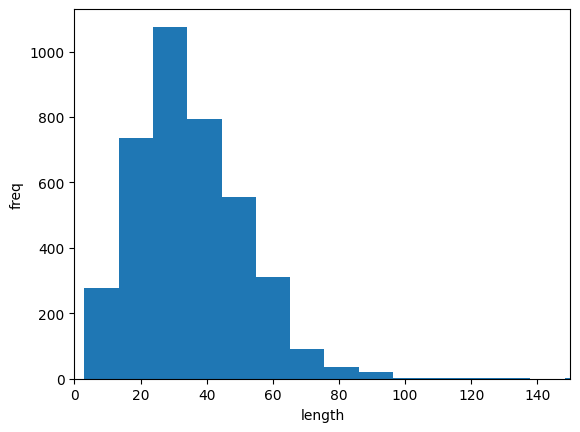

In [12]:
import matplotlib.pyplot as plt
plt.hist(count, bins=40)
plt.xlim(0, 150)
plt.xlabel('length')
plt.ylabel('freq')

## Data Processing

In [13]:
idx_to_label = set()
for label in labels:
    for tag in label:
        if tag not in idx_to_label:
            idx_to_label.add(tag)
idx_to_label = list(idx_to_label)

In [14]:
idx_to_label

['POS',
 '$',
 'UH',
 "''",
 'CD',
 'NNPS',
 'VBZ',
 '#',
 '.',
 'PRP$',
 ',',
 'WDT',
 ':',
 'MD',
 'VB',
 'CC',
 'EX',
 'SYM',
 'NNS',
 'JJR',
 'VBN',
 'RBS',
 'WP$',
 'VBP',
 'NNP',
 '-NONE-',
 'JJS',
 'RB',
 '-RRB-',
 'WP',
 'RP',
 'RBR',
 '-LRB-',
 'PRP',
 'LS',
 'VBG',
 '``',
 'DT',
 'NN',
 'VBD',
 'FW',
 'WRB',
 'JJ',
 'TO',
 'PDT',
 'IN']

In [15]:
label_to_idx = {label: idx for idx, label in enumerate(idx_to_label)}
label_to_idx

{'POS': 0,
 '$': 1,
 'UH': 2,
 "''": 3,
 'CD': 4,
 'NNPS': 5,
 'VBZ': 6,
 '#': 7,
 '.': 8,
 'PRP$': 9,
 ',': 10,
 'WDT': 11,
 ':': 12,
 'MD': 13,
 'VB': 14,
 'CC': 15,
 'EX': 16,
 'SYM': 17,
 'NNS': 18,
 'JJR': 19,
 'VBN': 20,
 'RBS': 21,
 'WP$': 22,
 'VBP': 23,
 'NNP': 24,
 '-NONE-': 25,
 'JJS': 26,
 'RB': 27,
 '-RRB-': 28,
 'WP': 29,
 'RP': 30,
 'RBR': 31,
 '-LRB-': 32,
 'PRP': 33,
 'LS': 34,
 'VBG': 35,
 '``': 36,
 'DT': 37,
 'NN': 38,
 'VBD': 39,
 'FW': 40,
 'WRB': 41,
 'JJ': 42,
 'TO': 43,
 'PDT': 44,
 'IN': 45}

In [16]:
train_text, test_text, train_label, test_label = train_test_split(texts, labels, test_size=0.2, random_state=42)

In [17]:
MAX_LENGTH = 70

In [18]:
def align_labels(label, word_ids):
    curr_word_id = None
    new_label = []
    for word_id in word_ids:
        if word_id is None or word_id == curr_word_id:
            new_label.append(-100)
        elif word_id != curr_word_id:
            new_label.append(label_to_idx[label[word_id]])
            curr_word_id = word_id
    return new_label

In [19]:
class POSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        super(POSDataset, self).__init__()
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        tokenized = self.tokenizer(text, is_split_into_words=True, 
                              padding='max_length', max_length=MAX_LENGTH,
                              truncation=True, return_tensors = 'pt')
        word_ids = tokenized.word_ids()
        new_label = align_labels(label, word_ids)
        inputs = {
            'input_ids': tokenized.input_ids.flatten(),
            'attention_mask': tokenized.attention_mask.flatten(),
            'labels': torch.as_tensor(new_label, dtype=torch.long)
        }
        return inputs

In [20]:
train_data = POSDataset(train_text, train_label, tokenizer)
test_data = POSDataset(test_text, test_label, tokenizer)

In [21]:
train_data[100]

{'input_ids': tensor([  101,  9308,  1010, 18015,  8390,  2228,  3996,  1005,  1055,  4121,
          2353,  1011,  4284,  2928,  7698,  1997,  2049, 18015, 11103,  2000,
          1002,  1018,  1012,  1018,  4551,  1008,  1057,  1008,  2001,  1050,
          1005,  1056,  2438,  1010,  1008,  3574,  1014,  2178,  2928,  7698,
          2071,  2022,  2746,  1012,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'labels': tensor([-100,   27,   10,   38,   18,   23,   24,    0, -100,   42,   38, -100,
         -100,   38, -100,   45,    9,   38,   38,   43,    1,    4, -100, -100,
   

In [22]:
BATCH_SIZE = 64
train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

## Model

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [24]:
from transformers import AutoModel
backbone = AutoModel.from_pretrained(model_name)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
backbone

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [26]:
backbone.config

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 30522
}

In [27]:
class POSClassifier(nn.Module):
    def __init__(self, num_classes, p):
        super(POSClassifier, self).__init__()
        self.encoder = backbone
        dim = self.encoder.config.dim
        self.fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Dropout(p),
            nn.GELU(),
            nn.Linear(dim, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        o1 = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        o2 = self.fc(o1.last_hidden_state)
        return o2.permute(0, 2, 1)

In [28]:
num_classes = len(idx_to_label) + 1

In [29]:
model = POSClassifier(num_classes=num_classes, p = 0.3).to(device)
model

POSClassifier(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linea

## Model Training

In [30]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [31]:
from tqdm import tqdm
from torch.nn.utils import clip_grad_norm_
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index = -100)

In [32]:
def train(epoch, epochs):
    model.train()
    correct, count, losses = 0, 0, []

    for inputs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        input_ids = inputs['input_ids'].to(device)
        attn_mask = inputs['attention_mask'].to(device)
        labels = inputs['labels'].to(device)
        optimizer.zero_grad()
        pred = model(input_ids,attn_mask) 
        # loss= pred.loss
        # logits = pred.logits
        loss = criterion(pred, labels)
        losses.append(loss.item())
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        pred_class = pred.argmax(1)
        mask = (labels != -100)
        _pred_class = pred_class[mask]
        correct += ( _pred_class == labels[mask]).sum().item()
        
        # count += len(_pred_class)
        count += _pred_class.numel()

    epoch_loss = sum(losses)/len(losses)
    epoch_acc = correct / count
    return epoch_acc, epoch_loss

def evaluate(epoch, epochs):
    model.eval()
    correct, count, losses = 0, 0, []
    with torch.no_grad():
        for inputs in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            input_ids = inputs['input_ids'].to(device)
            attn_mask = inputs['attention_mask'].to(device)
            labels = inputs['labels'].to(device)
            pred = model(input_ids,attn_mask, )
            loss = criterion(pred, labels)
            # logits = pred.logit
            losses.append(loss.item())
            pred_class = pred.argmax(1)
            mask = (labels != -100)
            _pred_class = pred_class[mask]
            correct += ( _pred_class == labels[mask]).sum().item()
            # count += len(labels)
            count += _pred_class.numel()

    epoch_loss = sum(losses)/len(losses)
    epoch_acc = correct / count
    # scheduler.step(epoch_loss)
    return epoch_acc, epoch_loss

In [33]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []
min_eval_loss = 10


In [34]:
def training(epochs, min_eval_loss):
    min_eval_loss = 10
    for epoch in range(epochs):
        train_acc, train_loss = train(epoch, epochs)
        val_acc, val_loss = evaluate(epoch, epochs)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")
        if val_loss < min_eval_loss:
            torch.save(model.state_dict(), 'best_model.bin')
            min_eval_loss = val_loss
            print(f"Checkpoint at epoch {epoch}")

In [35]:
training(10, min_eval_loss)

Epoch 1/10 [Val]: 100%|██████████| 13/13 [00:01<00:00,  8.73it/s]


  Train Loss: 1.9762, Train Acc: 58.06%
  Val Loss: 0.9391, Val Acc: 82.58%

Checkpoint at epoch 0


Epoch 2/10 [Val]: 100%|██████████| 13/13 [00:01<00:00,  8.47it/s]


  Train Loss: 0.6960, Train Acc: 86.03%
  Val Loss: 0.5854, Val Acc: 89.67%

Checkpoint at epoch 1


Epoch 3/10 [Val]: 100%|██████████| 13/13 [00:01<00:00,  8.29it/s]


...

  Train Loss: 0.4305, Train Acc: 90.88%
  Val Loss: 0.4343, Val Acc: 91.84%

Checkpoint at epoch 7


Epoch 9/10 [Val]: 100%|██████████| 13/13 [00:01<00:00,  7.56it/s]


  Train Loss: 0.4273, Train Acc: 90.89%
  Val Loss: 0.4289, Val Acc: 91.70%

Checkpoint at epoch 8


Epoch 10/10 [Val]: 100%|██████████| 13/13 [00:01<00:00,  7.47it/s]

  Train Loss: 0.4254, Train Acc: 90.91%
  Val Loss: 0.4350, Val Acc: 91.71%



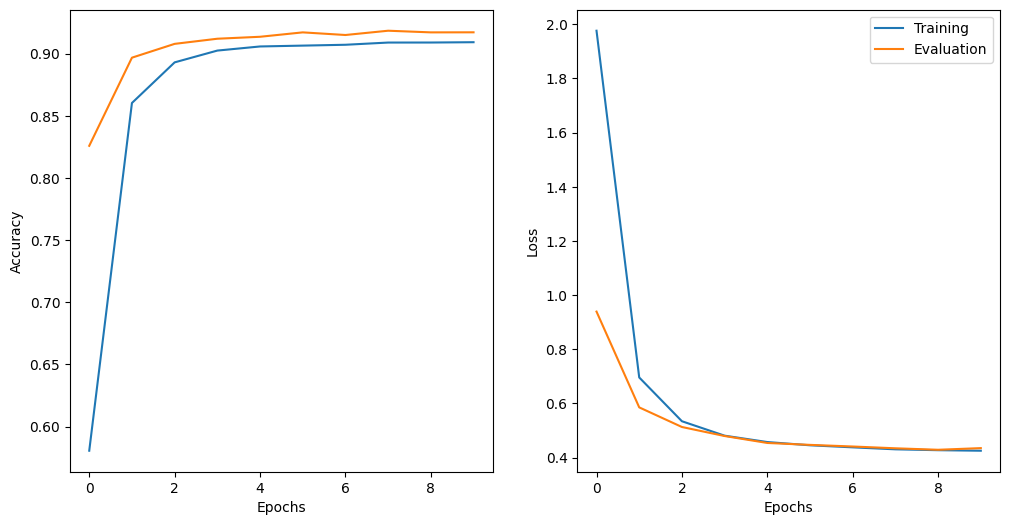

In [36]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
epochs = list(range(len(train_accs)))
axs[0].plot(epochs,train_accs, label = "Training")
axs[0].plot(epochs, val_accs, label = "Evaluation")
axs[1].plot(epochs, train_losses, label = "Training")
axs[1].plot(epochs, val_losses, label = "Evaluation")
axs[0].set_xlabel("Epochs")
axs[1].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Loss")
plt.legend()

In [37]:
output_dir = "./tokenizer"
# model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('./tokenizer/tokenizer_config.json', './tokenizer/tokenizer.json')